# CIFAR-10 MLP

In [1]:
import os
import pandas as pd
import numpy as np
from plt_rcs import *
import torch

In [2]:
plt.rc(group='figure', figsize=(4, 4))

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

In [4]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/dl'

In [5]:
os.chdir('../../data')

In [6]:
[i for i in os.listdir() if '.pkl' in i]

['Diabetes.pkl',
 'Facility_Sensor_Raw.pkl',
 'Used_Cars_Prep.pkl',
 'Facility_Sensor_Out.pkl',
 'Used_Cars.pkl',
 'Encar_Merged_Prep_20220711.pkl',
 'WhiteWine.pkl',
 'Cereal.pkl',
 'Bank_Customer.pkl',
 'Marine_Product.pkl',
 'MNIST_Dataset.pkl',
 'APT_Price.pkl',
 'CIFAR10_Dataset.pkl']

In [7]:
objs = pd.read_pickle('CIFAR10_Dataset.pkl')

In [8]:
globals().update(objs)

In [9]:
%whos

Variable        Type       Data/Info
------------------------------------
device          device     mps
np              module     <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
objs            dict       n=2
os              module     <module 'os' (frozen)>
pd              module     <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
plt             module     <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns             module     <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
test_cifar10    CIFAR10    Dataset CIFAR10\n    Numb<...>5, 0.2616])\n           )
torch           module     <module 'torch' from '/op<...>kages/torch/__init__.py'>
train_cifar10   CIFAR10    Dataset CIFAR10\n    Numb<...>5, 0.2616])\n           )


In [10]:
train_cifar10, test_cifar10 = train_cifar10, test_cifar10

In [11]:
os.chdir('../code/dl')

In [12]:
[i for i in os.listdir() if '.py' in i]

['gradcamviz.py', 'trainer.py', 'plt_rcs.py']

In [13]:
from trainer import Trainer, set_seed

In [14]:
set_seed(0)

In [15]:
from torch.utils.data import DataLoader

In [16]:
bs = 256

In [17]:
train_loader = DataLoader(dataset=train_cifar10, batch_size=bs, shuffle=True)
test_loader = DataLoader(dataset=test_cifar10, batch_size=bs, shuffle=False)

In [18]:
import torch.nn as nn

In [19]:
model = nn.Sequential(
    nn.Linear(in_features=3*32*32, out_features=1024),
    nn.ReLU(),
    nn.Linear(in_features=1024, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10),
).to(device)

In [20]:
sum([p.numel() for p in model.parameters() if p.requires_grad == True])

3411722

In [22]:
critertion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

In [26]:
trainer = Trainer(
    model=model,
    criterion=critertion,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=test_loader,
    flatten=True
)

[Trainer] Using device: mps:0


In [ ]:
history = trainer.fit(n_epochs=10)
# [Epoch 01] Loss = 1.6521, Train_Acc = 0.4852, Test_Acc = 0.4729
# [Epoch 02] Loss = 1.4277, Train_Acc = 0.5288, Test_Acc = 0.4870
# [Epoch 03] Loss = 1.3089, Train_Acc = 0.5787, Test_Acc = 0.5123
# [Epoch 04] Loss = 1.2214, Train_Acc = 0.6096, Test_Acc = 0.5187
# [Epoch 05] Loss = 1.1388, Train_Acc = 0.6290, Test_Acc = 0.5209
# [Epoch 06] Loss = 1.0538, Train_Acc = 0.6763, Test_Acc = 0.5418
# [Epoch 07] Loss = 0.9817, Train_Acc = 0.6928, Test_Acc = 0.5371
# [Epoch 08] Loss = 0.9041, Train_Acc = 0.7276, Test_Acc = 0.5418
# [Epoch 09] Loss = 0.8413, Train_Acc = 0.7421, Test_Acc = 0.5328
# [Epoch 10] Loss = 0.7690, Train_Acc = 0.7698, Test_Acc = 0.5327

[Epoch 01] Loss = 1.6521, Train_Acc = 0.4852, Test_Acc = 0.4729
[Epoch 02] Loss = 1.4277, Train_Acc = 0.5288, Test_Acc = 0.4870
[Epoch 03] Loss = 1.3089, Train_Acc = 0.5787, Test_Acc = 0.5123
[Epoch 04] Loss = 1.2214, Train_Acc = 0.6096, Test_Acc = 0.5187
[Epoch 05] Loss = 1.1388, Train_Acc = 0.6290, Test_Acc = 0.5209
[Epoch 06] Loss = 1.0538, Train_Acc = 0.6763, Test_Acc = 0.5418
[Epoch 07] Loss = 0.9817, Train_Acc = 0.6928, Test_Acc = 0.5371
[Epoch 08] Loss = 0.9041, Train_Acc = 0.7276, Test_Acc = 0.5418
[Epoch 09] Loss = 0.8413, Train_Acc = 0.7421, Test_Acc = 0.5328
[Epoch 10] Loss = 0.7690, Train_Acc = 0.7698, Test_Acc = 0.5327
Total training time: 0 min 41 sec


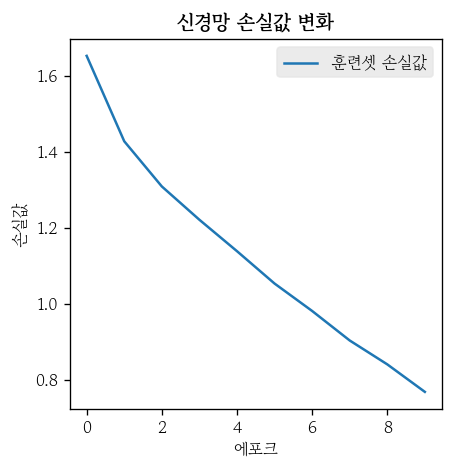

In [29]:
trainer.plot_loss()

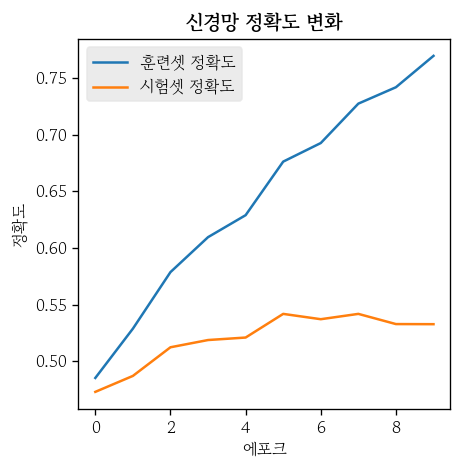

In [30]:
trainer.plot_accuracy()

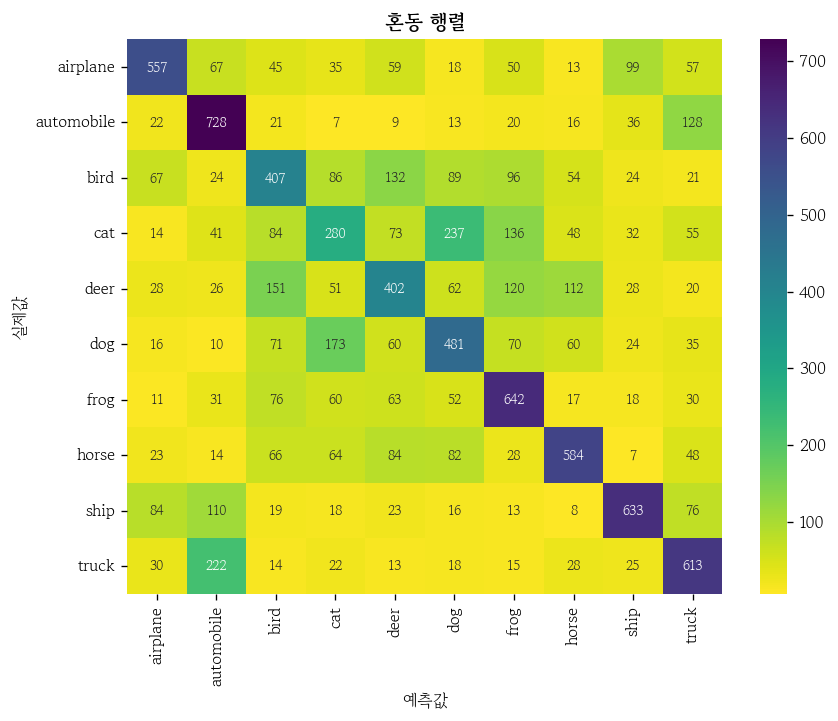

In [31]:
trainer.plot_confusion_matrix(data_loader=test_loader)

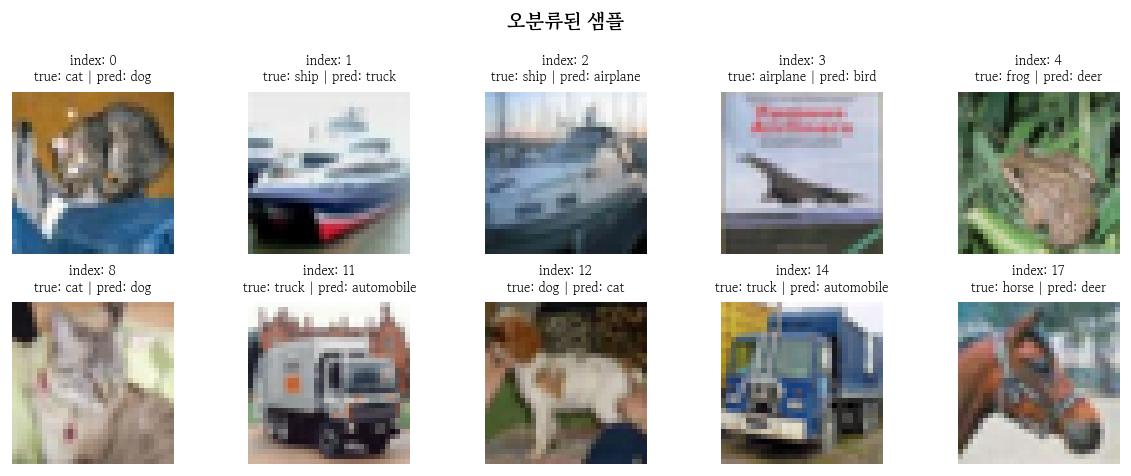

In [33]:
trainer.plot_misclassified(data_loader=test_loader, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616])